just neur nets (in a nutshell) ⚛️

# Tensor

mungkin udah pernah pada belajar yaa kalo 1 dimensi kek gini <br>
$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$
itu namanya vectors, terus klo 2 dimensi kek gini <br>
$$
\begin{bmatrix}
1 & 3 \\
2 & 6
\end{bmatrix}
$$
itu namanya matrix, terus klo yg dimensinya lebih dari 2? <br>
$$
\begin{bmatrix}
\begin{bmatrix}
\color{red}{1} & \color{red}{2}
\end{bmatrix}
&
\begin{bmatrix}
\color{red}{3} & \color{red}{4}
\end{bmatrix}
\\
\begin{bmatrix}
\color{red}{5} & \color{red}{6}
\end{bmatrix}
&
\begin{bmatrix}
\color{red}{7} & \color{red}{8}
\end{bmatrix}
\\
\begin{bmatrix}
\color{red}{9} & \color{red}{0}
\end{bmatrix}
&
\begin{bmatrix}
\color{red}{1} & \color{red}{2}
\end{bmatrix}
\end{bmatrix}
$$
gatau namanya? kasi nama tensors wkwk. Teori seriusnya ga gitu yaa, jadi smua itu tensors termasuk si vector cuma beda orde/dimensi aja

> tensor itu cuma sesimple generalisasi aja mulai dari scalar -> vector -> matriks dll <br>

In [6]:
import torch

## bit explanation

In [3]:
# 1. Scalar (Dimensi: 0)
# Tidak punya shape (scalar)
scalar = torch.tensor(10)
print(f"Scalar: {scalar}, Shape: {scalar.shape}")

Scalar: 10, Shape: torch.Size([])


In [4]:
# 2. Vector (Dimensi: 1)
# Punya panjang (panjang kolom)
vector = torch.tensor([1, 2, 3])
print(f"Vector: {vector}, Shape: {vector.shape}") 

Vector: tensor([1, 2, 3]), Shape: torch.Size([3])


In [5]:
# 3. Matrix (Dimensi: 2)
# Baris x Kolom
matrix = torch.tensor([[1, 2], [3, 4]])
print(f"Matrix:\n{matrix}, Shape: {matrix.shape}")

Matrix:
tensor([[1, 2],
        [3, 4]]), Shape: torch.Size([2, 2])


In [ ]:
# 4. Block Matrix (Dimensi: 3) -> orang umumnya malah nyebut tensor, pdahal smua tadi itu tensor wkkw
# Menggabungkan matriks-matriks
# Ini adalah kumpulan dari beberapa matriks
tensor_3d = torch.tensor([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]],
    [[9, 0], [1, 2]]
])
print(f"Tensor 3D:\n{tensor_3d}, Shape: {tensor_3d.shape}")
print(f'\n-> means ada {tensor_3d.shape[0]} matriks ukuran {tensor_3d.shape[1]}x{tensor_3d.shape[2]} dimensi')

Tensor 3D:
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]],

        [[9, 0],
         [1, 2]]]), Shape: torch.Size([3, 2, 2])
    
-> means ada 3 matriks ukuran 2x2 dimensi


In [ ]:
# Kalo 4d juga biasa kepake di Compvis image batch gitu
# jadi ada (B, C, H, W) -> batch, channel, height, width => (32,3,224,224)

# Computational Graph (sdikit lebi byk wkwk)

> kek tadi klo kita pake requires_grad gitu each opearationnya itu disimpen (netiher dieksek nor dilupain) dia bangun suatu Directed Acyclic Graph (DAG) tiap nodenya itu:
- leaf nodes: tensor input/params (weight, bias, input data)
- intermediate nodes: hasil operasinya (matmul, act funcion dll)
- edges: nah ini "petanya" kek tensor ini dipake buat generate tensor mana?<br>
Nah root dari graphnya itu adalah $L$. Graphnya dibuild dengan `forward` (saat ngecompute) terus dipake buat traverse backprop pas kita manggil `backward`

(maybe) ada yg nanya "kenapa perlu torch? bukannya kita bisa tackle case ini dg numpy?" nahh jawabannya adalah... <b>si numpy bisa ngestoring si angka2nya tapi dia gabisa nyimpen gradientnya </b><br>
a = np.array([1,2,5,7]) tapi klo si torch dia bisa pake si requires_grad => x = torch.tensor([1,2,5,7],requires_grad=True) -> jadi smua operasi thd tensor itu tu kecatet<br>
Jadi ga sekedar nyimpen angka tapi bisa tau opration historicalnya juga makanya dia bisa backprop

Graphnya penting scara matematis karna pd dasarnya di backprop itu kan "cuma" chain rule jadi bisa diapply sistematis lwat graph mechanism <br> <br>
$L = f(g(h(x)))$<br>
<br>maka chain rulenya:<br><br>
$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial f} . \frac{\partial f}{\partial g} . \frac{\partial g}{\partial h} . \frac{\partial h}{\partial x} $

- nah computational graph itu literally adalah representasi dari komposisi fungsi itu tadi. Di tiap node dia nyimpen `cara compute local gradientnya (turunan thd input langsungnya)` dan si backward itu `mengalikan local gradient scara brurutan dari ujung out ke input`

## grad_fn

Setiap non-leaf tensor punya atribut `.grad_fn` yang ngestore operasi apa yang menghasilkan dia, dan itu punya method `.backward()` sendiri yang tau cara compute local gradient-nya.

Jadi ada x = 2, w = 3, sama b = 1<br>
terus ada masing2 fungsi<br>
- $y = w.x$ -> 6 (msukin angka aj)
- $z = y+b$ -> 7
- $L = z^2$ -> 49<br><br>
Kita itung manual dlu yaa buat nanti bisa make sure codingannya<br>
- $\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \frac{\partial z}{\partial y} \frac{\partial L}{\partial x}$
    - $\frac{\partial L}{\partial z} = 2z$
    - $\frac{\partial z}{\partial y} = 1$
    - $\frac{\partial y}{\partial x} = w$
- jadi dia dapet $2zw$ => kalo kita masukin angkanya ke final resultnya jadi 2(7)(3) = 42 (nanti liat resultnya di codingan ⬇️⬇️⬇️)


In [3]:
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x        
z = y + b         
L = z ** 2        

print('y.grad_fn:', y.grad_fn)
print('z.grad_fn:', z.grad_fn)
print('L.grad_fn:', L.grad_fn)
print()
print('x.is_leaf:', x.is_leaf, '| y.is_leaf:', y.is_leaf)

L.backward()
print()
print('dL/dx =', x.grad.item())
print('dL/dw =', w.grad.item())
print('dL/db =', b.grad.item())

y.grad_fn: <MulBackward0 object at 0x1123f3a00>
z.grad_fn: <AddBackward0 object at 0x1123f31c0>
L.grad_fn: <PowBackward0 object at 0x1123f3a00>

x.is_leaf: True | y.is_leaf: False

dL/dx = 42.0
dL/dw = 28.0
dL/db = 14.0


hasilnya udah fit, nah inilah yg sebenernya terjadi dibalik layar `backward` itu dia ngetravese graph dari root out ke in, terus ngalikan each local gradientnya, terusss propagate sampe kebelakang, tamat...

#### sdikit trivia

Btw klo tensornya itu bukan scalar (eg batch of outputs gt) `.backward` itu sbnernya bukan compute gradient biasa, tapi <b>Vector Jacobian Product (VJP)</b>. Kalau $y = f(x)$ dengan jacobian $J=\frac{\partial y}{\partial x}$, dan kita panggil y.backward(v) dengan suatu vektor v (biasanya $\frac{\partial L}{\partial x}$ dari layer diatasnya), torch ngecompute: <br> $v^T J$ <br>
jadi <b>bukan full jacobian</b> krena yaa terlalu expensive bget buat network gede. Makanya utk non scalar kan kita kasi argument tambahan `gradient=...`

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2   # y = [x1^2, x2^2, x3^2], vector output!

# y bukan scalar, jadi backward butuh 'v' (upstream gradient)
v = torch.tensor([1.0, 1.0, 1.0])  # anggap dL/dy = [1,1,1]
y.backward(v)

print('x.grad (v^T J):', x.grad)
# Jacobian J = diag(2x) = diag([2,4,6])
# v^T J = [1,1,1] @ diag([2,4,6]) = [2,4,6]

# Multi Layer Perceptron, _ceilah_

masukla kita ke layer paling fundamental brow `nn.Linear()`

In [ ]:
# biasanya nih yaa klo kita ada code gini ⬇️
layer = nn.Linear(3,2)
# org umumnya bilang itu tu isinya layer, padahal itu isinya weight sm biasnya
# misal kita punya input x = [1,2,3] ada 3 fitur n kita pngen output 2 neuron => 3 in -> 2 out

```
x₁ ----\
        \
x₂ ------> y₁
        /
x₃ ----/

x₁ ----\
        \
x₂ ------> y₂
        /
x₃ ----/
```

- Output pertama punya 3 weight.
- Output kedua punya 3 weight.
- Total 6 weight ditambah 2 bias
- Total parameter 8 parameter

## Bentuk weight

Karena 3 input
=> 2 output, Weight harus:
$$
\begin{bmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23} 
\end{bmatrix}
$$
-> shapenya (2,3) wkwk bingung yak 🤔 iya karena emg si torch itu nyimpennya (out_features, in_features)


misal kita forward pass manual pake $y = Wx+b$
- inputnya x = 
$$
\begin{bmatrix}
1 \\
2 \\
3
\end{bmatrix}
$$
- weightnya = 
$$
\begin{bmatrix}
1 & 2 & 3\\ 
4 & 5 & 6\\ 
\end{bmatrix}
$$
- bias = 
$$
\begin{bmatrix}
10 \\ 20
\end{bmatrix}
$$

💡 Perhitungan <br>
- 1st neuron = 1(1)+2(2)+3(3) + 10 = 24
- 2nd neuron = 4(1)+5(2)+6(3) + 20 = 52
- outnya jadi = 
$$
\begin{bmatrix}
24\\52
\end{bmatrix}
$$

In [8]:
# manualnya klo gapake nn.Linear 
x = torch.tensor([1.,2.,3.]) 
w = torch.tensor([
    [1.,2.,3.],
    [4.,5.,6.],
],requires_grad=True) #btw kita pake float itu krena klo req grad cuma bisa di float or complex num
b = torch.tensor([10.,20.],requires_grad=True)

y = w@x+b
print(y) # hasilnya must be sama kek yg manual ⬆️

tensor([24., 52.], grad_fn=<AddBackward0>)


In [9]:
# ni klo buat pake class
class MiniLinear:
    def __init__(self,in_features,out_features):
        self.weight = torch.randn(
            out_features,
            in_features,
            requires_grad=True
        )

        self.bias = torch.randn(
            out_features,
            requires_grad=True
        )

    def forward(self,x):
        return self.weight @ x + self.bias

In [10]:
layer = MiniLinear(3,2)

x = torch.tensor([1.,2.,3.])

y = layer.forward(x)

print(y)

tensor([-1.9892,  1.1377], grad_fn=<AddBackward0>)


## (Sedikit Banyak) ttg pernak pernik neur nets

### activation function

btw kenapa sik kita need act function? klo misal `linear diterusin linear layer terusssss...` intinya kaga jadi apa2 tep linear sampe ujung, let say kita punya
- 1st layer -> y = x+5
- 2nd layer -> z = 2y+2
- 3rd layer -> n = 8z
jadinya dia 8(2(x+5)+2) at the end kan tetep satu linear, nah kita gamau kek gitu tuu, jadi kita perlu non linear biar dia bisa learn pattern dan ga patah layer per layernya ngalir trs.

In [11]:
# di torch sbenernya gampang tinggal torch.relu, klo mentahannya gini bro ⬇️
def fungsi_relu(x):
    return torch.maximum(x,torch.tensor(0.0))

In [12]:
# sigmoid sama juga (btw yg aku tulis disini yg aku inget aja wkwk)
def fungsi_sigmoid(x):
    return 1 / (1+torch.exp(-x)) 

### Loss func

msial kita bikin model tasknya tu ngeclassify 3 hewan ini
- 🐱 Kucing
- 🐮 Sapi
- 🐦 Burung <br>
Output neuronnya masing2:
<br>**[CASE 1]**<br>
- K: 0.7
- S: 0.2
- B: 0.1
<br> Nah ground truthnya itu adalah Kucing, nah ai perlu dikasi punishment kah?
<br> -> iyaa karena dia ga yakin 100%, tapi sberapa gede punishmentnya?
<br>**[CASE 2]**<br>
- K: 0.6
- S: 0.3
- B: 0.1
<br> gimana? masi bener dia krna yg dipredict cat tapi modelnya makin ga yakin, punishmentnya kek CASE 1? 🤔
<br>**[CASE 3]**<br>
- K: 0.01
- S: 0.98
- B: 0.01
<br> nah inimah dah opsed masa dia predict sapi, punishment sama kek yg seblumnya? SURELY GA DONG YAA WKWK



Disinilah kita butuh fungsi buat ngitung lossnya, what we really need..
- nyari fungsi dimana klo probabilitynya mendekati 1 yaa lossnya mendekati 0
- klo dia dpet proba 50:50 yaa lossnya sedang aja
- klo diaa probanya deket ke 0 yaaa lossnya ledakin duar 💥💥💥 

In [ ]:
# misal kita coba2 loss yaaa
def loss(p):
    return 1-p

print(f'proba gede: {loss(0.99):2f}')
print(f'proba sedang: {loss(0.5):2f}')
print(f'proba kecil: {loss(0.00001):2f}')

proba gede: 0.010000
proba sedang: 0.500000
proba kecil: 0.999990


sadar ga? lossnya dia proba gede sama kecil ga beda jauh, harusnya si proba kecil itu dikasi punishment yg lebi berasa. Oke gimana klo kita pake loss lain

In [ ]:
def loss2(p):
    return 1/p

print(f'proba gede: {loss2(0.99):2f}')
print(f'proba sedang: {loss2(0.5):2f}')
print(f'proba kecil: {loss2(0.00001):2f}')

proba gede: 1.010101
proba sedang: 2.000000
proba sedang: 1.176471
proba kecil: 100000.000000


nah ini dah makin jauh, cuma problemnya ktika dia deket ke 1 fungsinya kurang smooth, optimizationnya jadi struggle <br>
Untuk jawab itu smua scientist nemuin sifat dari suatu fungsi yg kita needs, wut? yoi bner logarithmic <br> -$\ln (x)$.

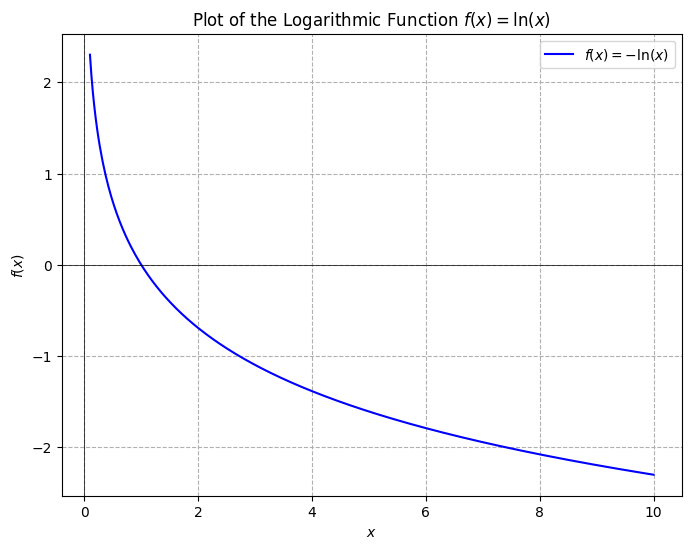

In [21]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.1, 10, 400)

y = - np.log(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = -\ln(x)$', color='blue')

plt.title(r'Plot of the Logarithmic Function $f(x) = \ln(x)$')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, which='both', linestyle='--')
plt.legend();